# EDA

In [101]:
train_size = 0.65

In [102]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
data = pd.read_csv('raw_sales.csv')
data.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [104]:
df = data.copy()
df = df.rename(columns={'datesold': 'date', 'propertyType': 'type'})
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,postcode,price,type,bedrooms
0,2007-02-07,2607,525000,house,4
1,2007-02-27,2906,290000,house,3
2,2007-03-07,2905,328000,house,3
3,2007-03-09,2905,380000,house,4
4,2007-03-21,2906,310000,house,3


In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      29580 non-null  datetime64[us]
 1   postcode  29580 non-null  int64         
 2   price     29580 non-null  int64         
 3   type      29580 non-null  str           
 4   bedrooms  29580 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(1)
memory usage: 1.1 MB


type
house    647956.128462
unit     423106.557279
Name: price, dtype: float64


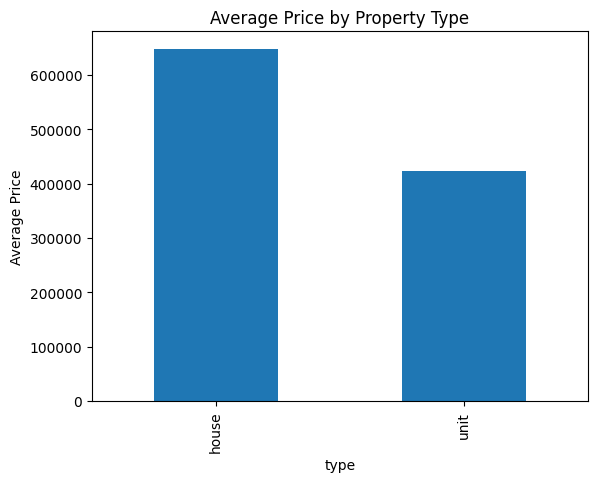

In [106]:
avg_price_by_type = df.groupby('type')['price'].mean().sort_values(ascending=False)
print(avg_price_by_type)
avg_price_by_type.plot(kind='bar', title='Average Price by Property Type')
plt.ylabel('Average Price')
plt.show()

bedrooms
5    919056.058974
4    718171.142023
3    552304.428140
0    542300.000000
2    442222.917454
1    335992.905962
Name: price, dtype: float64


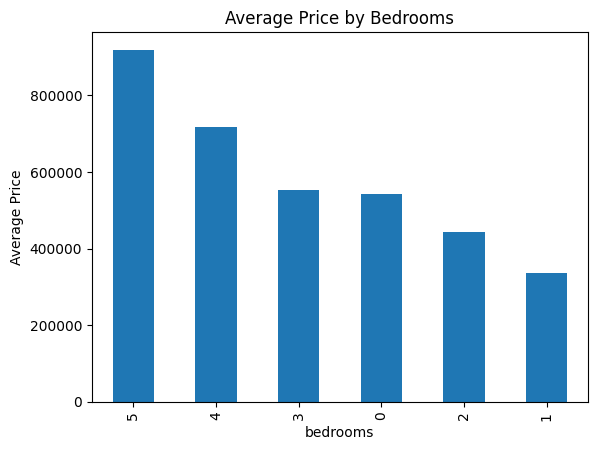

In [107]:
avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)
print(avg_price_by_bedrooms)

avg_price_by_bedrooms.plot(kind='bar', title='Average Price by Bedrooms')
plt.ylabel('Average Price')
plt.show()

# MISSING VALUES

The number of bedrooms 0 can be considered as missing values, as it is unlikely that a property would have zero bedrooms. It is possible that these entries were either not recorded correctly. To handle these missing values, we can either impute them with a reasonable value (such as the median number of bedrooms for that property type) or we can choose to drop those rows from the dataset if they are not significant in number.

In [108]:
# KNNImputer

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

def imputer_pipeline(df):

    df2 = df.copy()

    df2['bedrooms'] = df2['bedrooms'].replace(0,np.nan)

    le = LabelEncoder()
    df2['type_encoded'] = le.fit_transform(df2['type'])

    features = ['price', 'type_encoded', 'bedrooms']
    X = df2[features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    imputer = KNNImputer(n_neighbors=5, weights='distance')
    X_imputed = imputer.fit_transform(X_scaled)
    X_unscaled = scaler.inverse_transform(X_imputed)
    df2['bedrooms'] = X_unscaled[:,2]

    df2['bedrooms'] = df2['bedrooms'].round().astype(int)
    df2['bedrooms'] = df2['bedrooms'].clip(lower=1, upper=5)
    df2['bedrooms'].value_counts()

    return df2

In [109]:
#print the different values that bedrooms assumes when type == 'unit'
print(df[df['type'] == 'unit']['bedrooms'].unique())

[2 3 1 0 4 5]


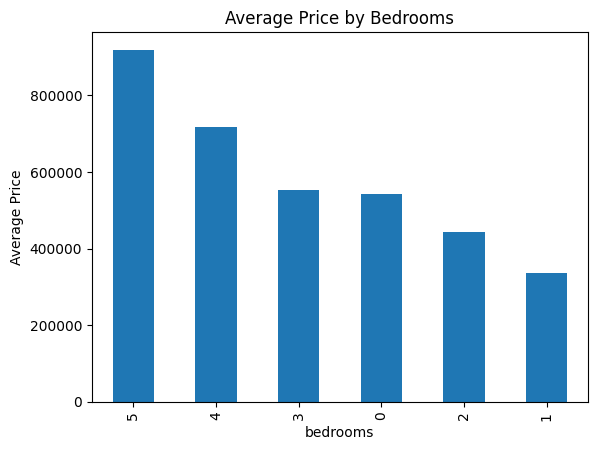

In [110]:
avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)

avg_price_by_bedrooms.plot(kind='bar', title='Average Price by Bedrooms')
plt.ylabel('Average Price')
plt.show()

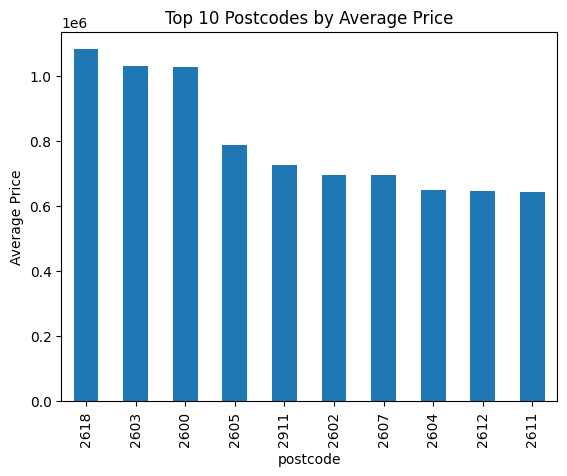

In [111]:
avg_price_by_postcode = df.groupby('postcode')['price'].mean().sort_values(ascending=False).head(10)

avg_price_by_postcode.plot(kind='bar', title='Top 10 Postcodes by Average Price')
plt.ylabel('Average Price')
plt.show()

In [112]:
df.columns


Index(['date', 'postcode', 'price', 'type', 'bedrooms'], dtype='str')

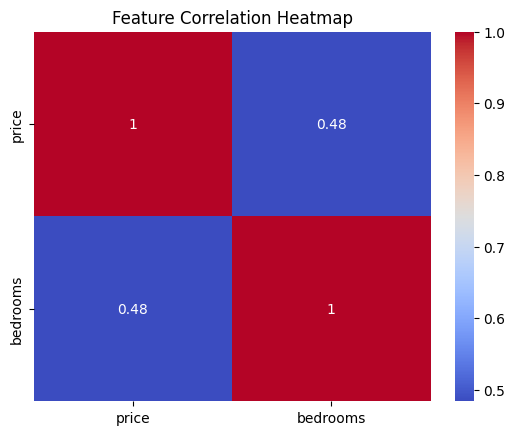

In [113]:
numeric_features = ['price', 'bedrooms']
sns.heatmap(df[numeric_features].corr(numeric_only=True),annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

The fact that the correlation between price and bedrooms is 0.49 suggests that there is a moderate positive relationship between the two variables. This means that, in general, as the number of bedrooms increases, the price tends to increase as well. However, it is not a very strong correlation, indicating that there are other factors influencing the price of the properties besides just the number of bedrooms.

# OUTLIERS

In [114]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Outliers detected: {len(outliers)}")

Outliers detected: 1374


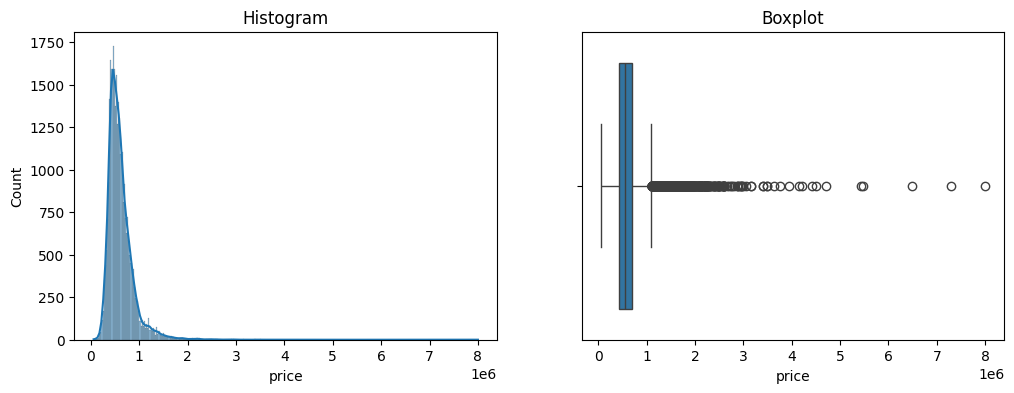

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_distribution(df, column):
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    
    sns.histplot(df[column], kde=True, ax=ax[0])
    ax[0].set_title("Histogram")
    
    sns.boxplot(x=df[column], ax=ax[1])
    ax[1].set_title("Boxplot")
    
    plt.show()

visualize_distribution(df, 'price')

Since it's right skewed, we can apply a log transformation to the price variable to make it more normally distributed. This can help improve the performance of certain machine learning algorithms that assume normality in the data, such as linear regression. After applying the log transformation, we can visualize the distribution again to confirm that it has become more normal.

In [116]:
def plot_price_distribution(df):
    plt.figure(figsize=(10, 6))
    sns.histplot(df['price'], kde=True)
    plt.title('Distribution of Property Prices')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

def plot_price_trend(monthly):
    plt.figure(figsize=(12, 6))
    plt.plot(monthly.index, monthly['price'], color='lightgray', label='Original', linewidth=1.5)
    plt.plot(monthly.index, monthly['price_rolling'], color='blue', label='Smoothed', linewidth=2)
    plt.title('Median Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Median Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_monthly_trend(monthly_df):
    monthly_df[['price', 'avg_bedrooms', 'house_ratio', 'sales_count']].plot(
        subplots=True, figsize=(10, 8), title='Monthly Trends')
    plt.tight_layout()
    plt.show()

In [117]:
from sklearn.preprocessing import PowerTransformer

def pipeline(df, type_of_outlier, plotting=True):

    # we can try different types of handling right-skewed outliers: simply removing them, using log transformation, using power transformation.
    #the first option is to simply remove the outliers from the dataset, which can be done by filtering out the rows that contain outlier values based on a defined threshold (e.g., using the IQR method or Z-score method). This approach can help improve the performance of machine learning models by reducing the influence of extreme values, but it may also lead to loss of valuable information if not done carefully.
    #the second option is to apply a log transformation to the price variable, which can help reduce the impact of outliers and make the distribution more normal. This can be done by creating a new column in the dataframe that contains the log-transformed values of the price variable. This approach can be effective in improving the performance of certain machine learning algorithms that assume normality in the data, such as linear regression
    #the third option is to apply a power transformation to the price variable, which can also help reduce the impact of outliers

    if type_of_outlier == 'none':
        df_cleaned = df.copy()

    elif type_of_outlier == 'remove':
        Q1 = df['price'].quantile(0.25)
        Q3 = df['price'].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_cleaned = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
        
    elif type_of_outlier == 'log_transform':
        df_cleaned = df.copy()
        df_cleaned['price'] = np.log(df_cleaned['price'])
    
    elif type_of_outlier == 'power_transform':
        df_cleaned = df.copy()
        pt = PowerTransformer(method='box-cox') # since price is positive, we can use box-cox transformation.  
        df_cleaned['price'] = pt.fit_transform(df_cleaned[['price']])

    #plot the distribution of the price variable after handling outliers
    if plotting:
        plot_price_distribution(df_cleaned)

    monthly = df_cleaned.resample('ME', on='date').agg({'price':'median'})
    monthly['price_rolling'] = monthly['price'].rolling(window=3, center=True).mean()

    #plot the original and smoothed median price over time
    if plotting:
        plot_price_trend(monthly)
    
    df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
    df_cleaned['month'] = df_cleaned['date'].dt.to_period('M')

    monthly_df = (df_cleaned.groupby('month').agg(
          price=('price', 'median'),
          house_ratio=('type', lambda x: (x == 'house').mean()),
          avg_bedrooms=('bedrooms', 'mean'),
          sales_count=('price', 'count')
     )
     .reset_index()
    )

    monthly_df['month'] = monthly_df['month'].dt.to_timestamp() # Convert Period to Timestamp for plotting (e.g. 2020-01-01 for January 2020)
    monthly_df.set_index('month', inplace=True)

    # if plotting:
    #     monthly_df.head()

    if plotting:
        plot_monthly_trend(monthly_df)

    return df_cleaned, monthly, monthly_df

The reason why we need house_ratio (house_ratio=('type', lambda x: (x == 'house').mean())) is to calculate the proportion of properties that are classified as 'house' within each month. This can provide insights into the distribution of property types over time and how it may relate to price trends. By including this ratio in our analysis, we can better understand the composition of the housing market and how it may influence median prices.

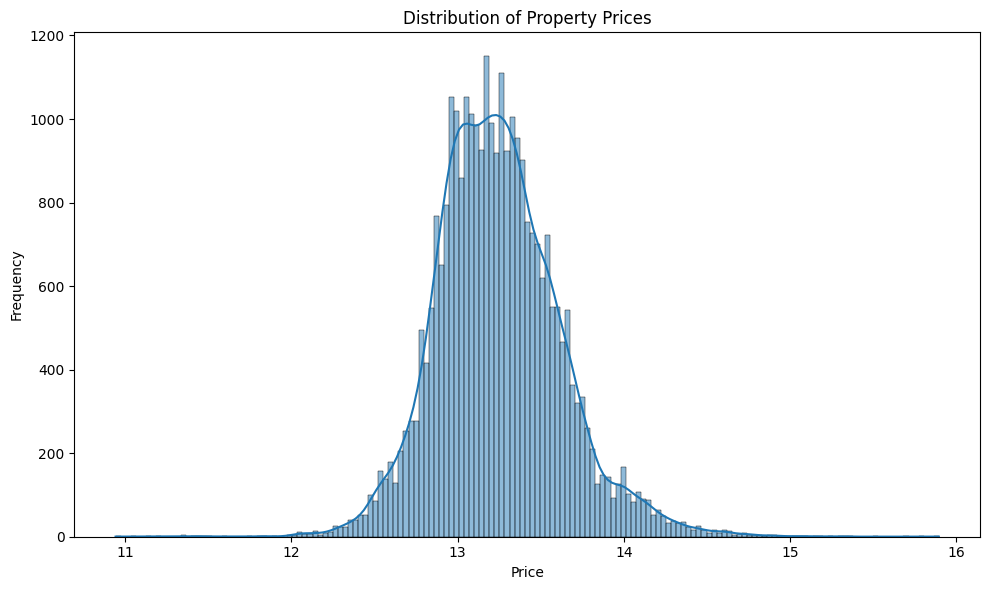

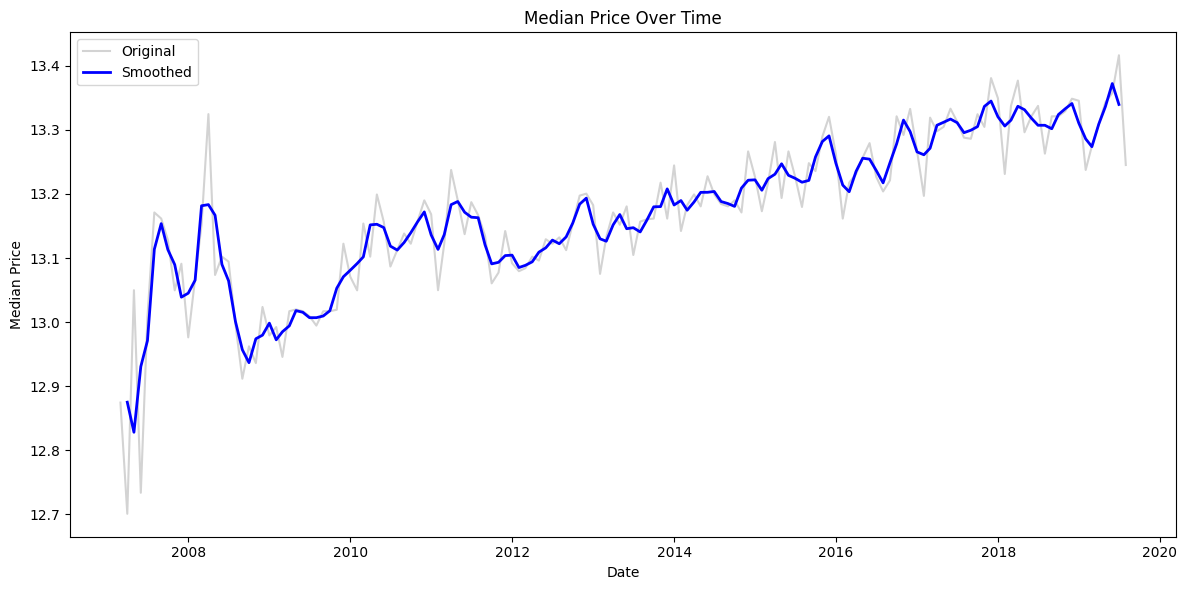

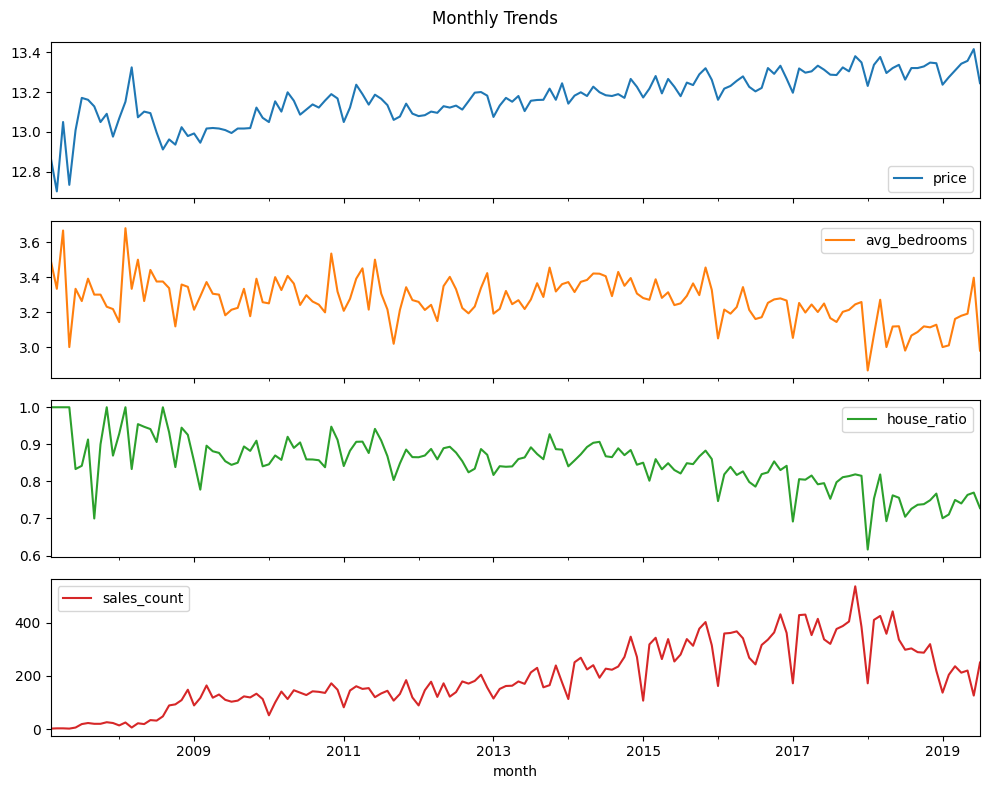

,price,house_ratio,avg_bedrooms,sales_count
month,,,,
2007-02-01,12.874395,1.000000,3.500000,2
2007-03-01,12.700769,1.000000,3.333333,3
2007-04-01,13.049793,1.000000,3.666667,3
2007-05-01,12.733577,1.000000,3.000000,2
2007-06-01,13.008398,0.833333,3.333333,6


In [118]:
_,_,monthly_df = pipeline(df, type_of_outlier='log_transform', plotting=True)
monthly_df.head()

In [119]:
#print average house price vs average unit price
avg_price_by_type = df.groupby('type')['price'].mean()
print(avg_price_by_type)

type
house    647956.128462
unit     423106.557279
Name: price, dtype: float64


# MEDIAN PRICE BY MONTH FORECAST WITH ML MODELS

### Random Forest Regressor


--- Handling outliers with method: none ---
Random Forest RMSE: $62,004.69


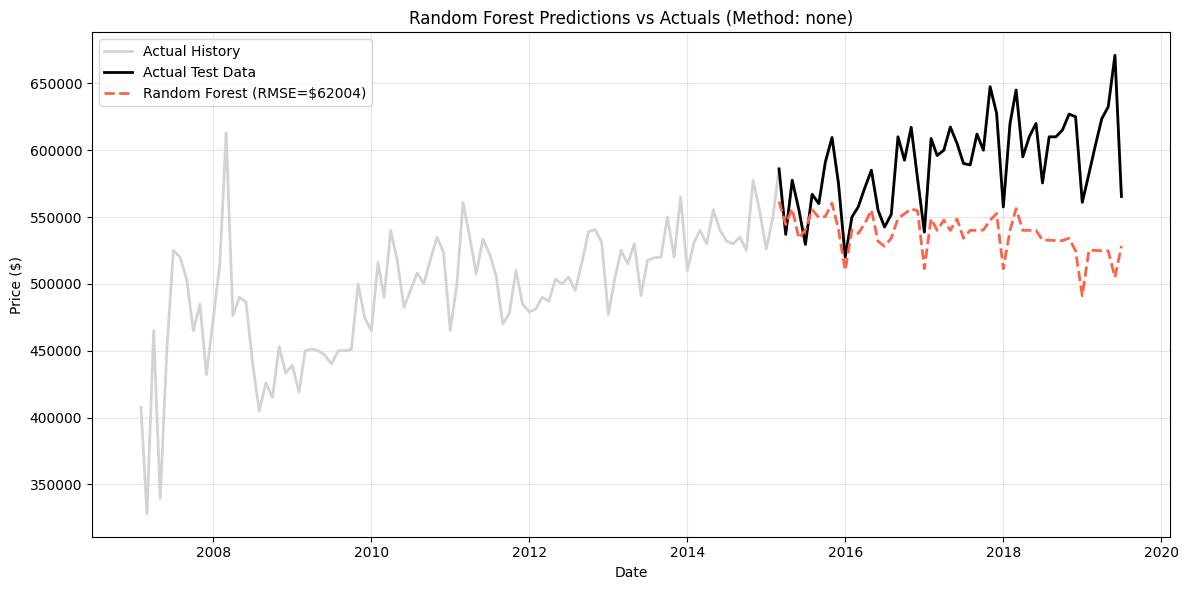

Feature importance for none:
sales_count     0.630311
avg_bedrooms    0.225534
house_ratio     0.144155
dtype: float64


--- Handling outliers with method: remove ---
Random Forest RMSE: $55,696.07


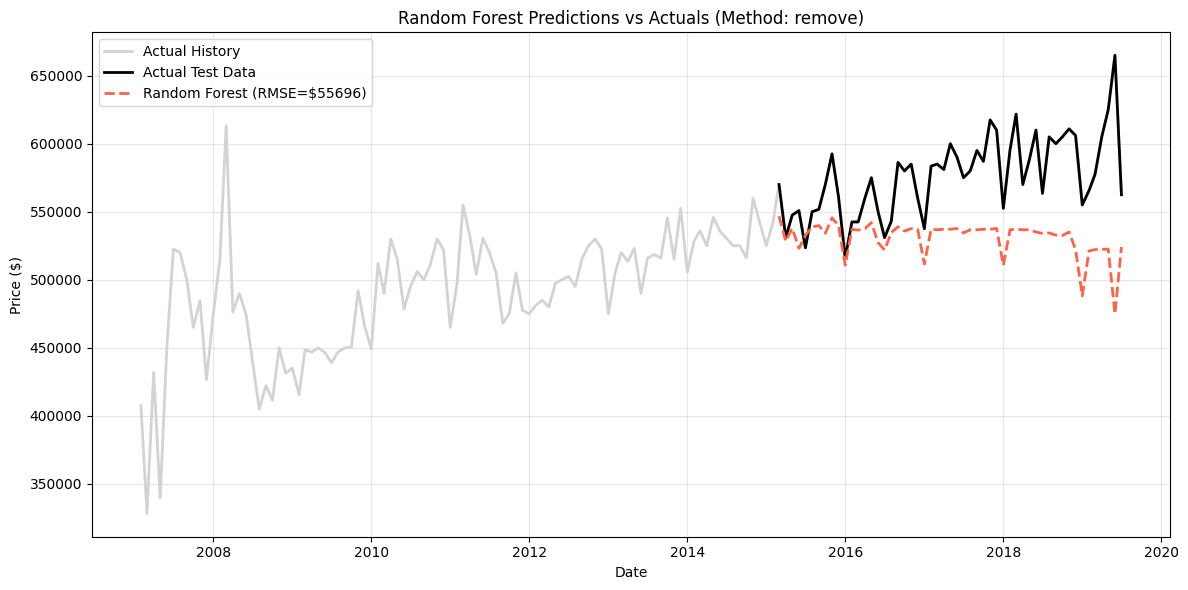

Feature importance for remove:
sales_count     0.639424
avg_bedrooms    0.204944
house_ratio     0.155632
dtype: float64


--- Handling outliers with method: log_transform ---
Random Forest RMSE: $63,926.53


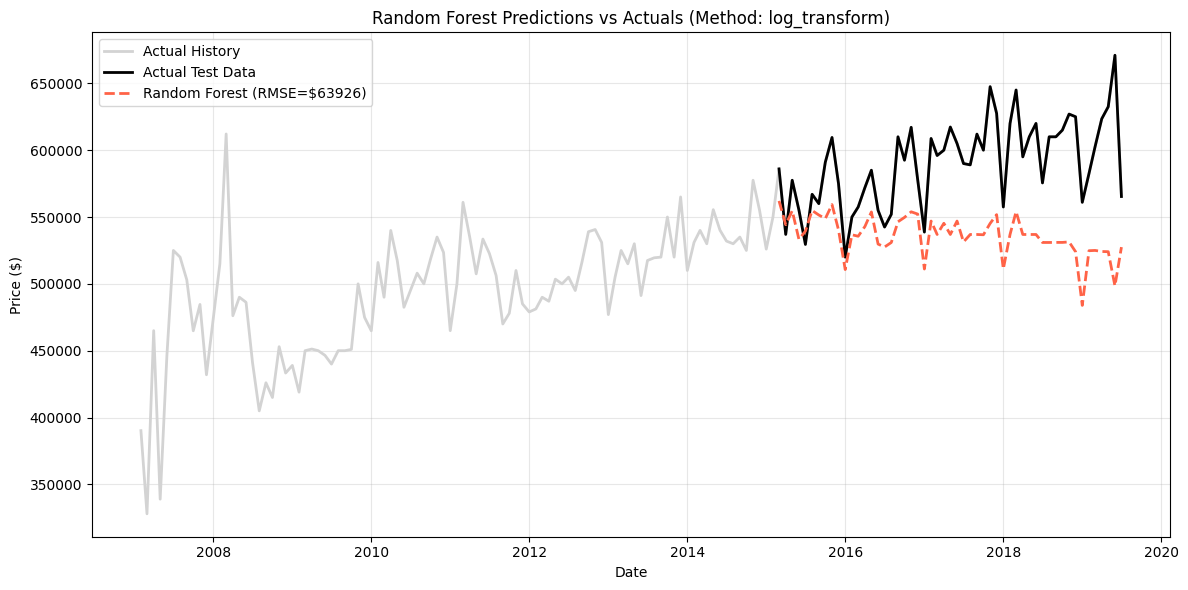

Feature importance for log_transform:
sales_count     0.638449
avg_bedrooms    0.219829
house_ratio     0.141722
dtype: float64



In [120]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import mean_squared_error
import math

# Function to calculate RMSE in Dollars
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

for type_of_outlier in ['none', 'remove', 'log_transform']: #'power_transform']:
    print(f"\n--- Handling outliers with method: {type_of_outlier} ---")

    # 1. Get the NEW data from the pipeline
    df_cleaned, monthly, monthly_df_cleaned = pipeline(df, type_of_outlier=type_of_outlier, plotting=False)

    # 2. Update Train/Test splits using the NEW monthly_df_cleaned
    split_idx = int(len(monthly_df_cleaned) * train_size)
    train = monthly_df_cleaned.iloc[:split_idx]
    test = monthly_df_cleaned.iloc[split_idx:]

    # 3. Re-define X and y
    y_train = train['price']
    y_test  = test['price']
    X_train = train[['avg_bedrooms', 'house_ratio', 'sales_count']]
    X_test  = test[['avg_bedrooms', 'house_ratio', 'sales_count']]

    # 4. Train the Random Forest model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    # 5. Inverse-transform to Dollars when using log-transform,
    #    otherwise keep prices as they are
    if type_of_outlier == 'log_transform':
        actual_dollar = np.exp(y_test.values)
        preds_dollar = np.exp(predictions)
        history_dollar = np.exp(monthly_df_cleaned['price'].values)
    elif type_of_outlier == 'power_transform':
        actual_dollar = np.power(10, y_test.values)
        preds_dollar = np.power(10, predictions)
        history_dollar = np.power(10, monthly_df_cleaned['price'].values)
    else:
        actual_dollar = y_test.values
        preds_dollar = predictions
        history_dollar = monthly_df_cleaned['price'].values

    # 6. Calculate RMSE in Dollars
    rmse_rf = calculate_rmse(actual_dollar, preds_dollar)
    print(f"Random Forest RMSE: ${rmse_rf:,.2f}")

    # 7. Plotting (similar style to the LSTM plots)
    full_dates = monthly_df_cleaned.index
    test_dates = test.index

    plt.figure(figsize=(12, 6))
    
    # Plot Full History
    plt.plot(full_dates, history_dollar, label='Actual History', color='lightgray', linewidth=2)
    plt.plot(test_dates, actual_dollar, label='Actual Test Data', color='black', linewidth=2)
    
    # Plot Predictions
    plt.plot(test_dates, preds_dollar, label=f'Random Forest (RMSE=${int(rmse_rf)})', color='tomato', linestyle='--', linewidth=2)

    plt.title(f'Random Forest Predictions vs Actuals (Method: {type_of_outlier})')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 8. Feature importance and partial dependence (kept from original cell)
    feature_importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print(f"Feature importance for {type_of_outlier}:\n{feature_importance}\n")

    #PartialDependenceDisplay.from_estimator(model, X_train, ["house_ratio"])
    #plt.suptitle(f"Partial Dependence of Price on House Ratio ({type_of_outlier})", y=1.02)
    #plt.show()

### LSTM

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [122]:
def create_sequences(X, y, seq_len=12):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

def run_lstm_multivariate(monthly_df_cleaned, train_size):

    '''
    This function runs a multivariate LSTM model using the 'avg_bedrooms', 'house_ratio', and 'sales_count' features from monthly_df_cleaned to predict the 'price' target.
    It scales the features and target, creates sequences, trains the LSTM, and returns predictions, actual values, and MSE.
    Multivariate means we are using multiple features (avg_bedrooms, house_ratio, sales_count) to predict the price, which allows the model to learn from the relationships between these features and the target variable.
    '''

    features = ['avg_bedrooms', 'house_ratio', 'sales_count', 'price']
    target = 'price'

    # ----- Scale data -----
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(monthly_df_cleaned[features])
    y_scaled = scaler_y.fit_transform(monthly_df_cleaned[[target]])

    # ----- Create sequences -----
    seq_len = 12
    X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_len)

    split_idx = int(len(X_seq) * train_size)
    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

    # ----- Build model -----
    model = Sequential([
        LSTM(64, return_sequences=False, input_shape=(seq_len, X_train.shape[2])),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=40, batch_size=16, verbose=0)

    # ----- Predict -----
    preds_scaled = model.predict(X_test)
    preds = scaler_y.inverse_transform(preds_scaled)
    y_test_real = scaler_y.inverse_transform(y_test)

    mse = mean_squared_error(y_test_real, preds)

    return preds, y_test_real, mse

def run_lstm_univariate(monthly_df_cleaned, train_size=train_size):
    '''
    This function runs a univariate LSTM model using only the 'price' column from monthly_df_cleaned.
    It scales the price data, creates sequences, trains the LSTM, and returns predictions, actual values, and MSE.
    Univariate means we are only using the price history to predict future prices, without any additional features.
    '''

    scaler = MinMaxScaler()
    price_scaled = scaler.fit_transform(monthly_df_cleaned[['price']])

    seq_len = 12
    X_seq, y_seq = create_sequences(price_scaled, price_scaled, seq_len)

    split_index = int(len(X_seq) * train_size)
    X_train, X_test = X_seq[:split_index], X_seq[split_index:]
    y_train, y_test = y_seq[:split_index], y_seq[split_index:]

    model = Sequential([
        LSTM(64, input_shape=(seq_len, 1)),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=40, batch_size=16, verbose=0)

    preds_scaled = model.predict(X_test)
    preds = scaler.inverse_transform(preds_scaled)
    y_test_real = scaler.inverse_transform(y_test)

    mse = mean_squared_error(y_test_real, preds)

    return preds, y_test_real, mse



--- Handling outliers with method: none ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Univariate LSTM RMSE:   $33,544.45
Multivariate LSTM RMSE: $33,253.69


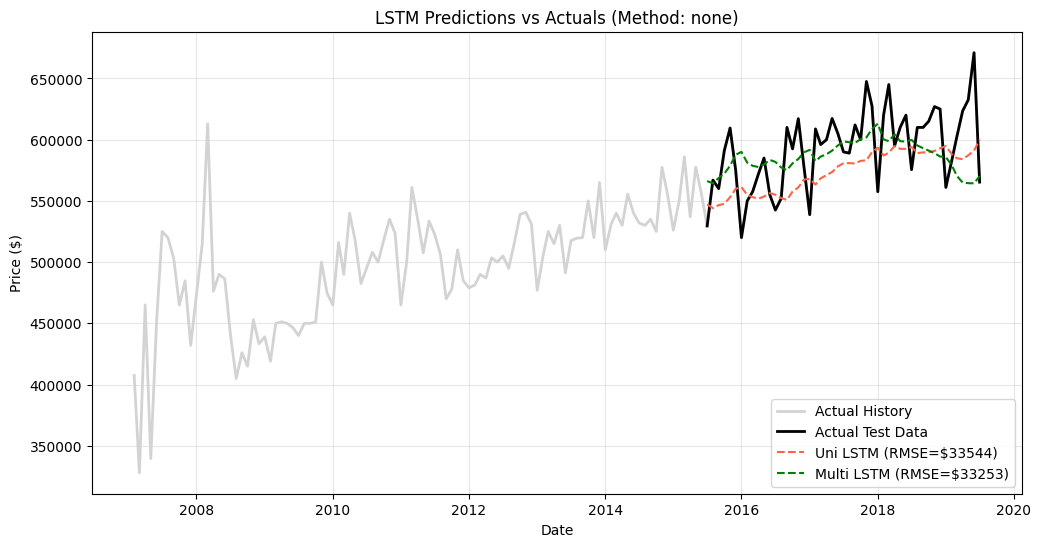


--- Handling outliers with method: remove ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Univariate LSTM RMSE:   $30,306.72
Multivariate LSTM RMSE: $27,744.01


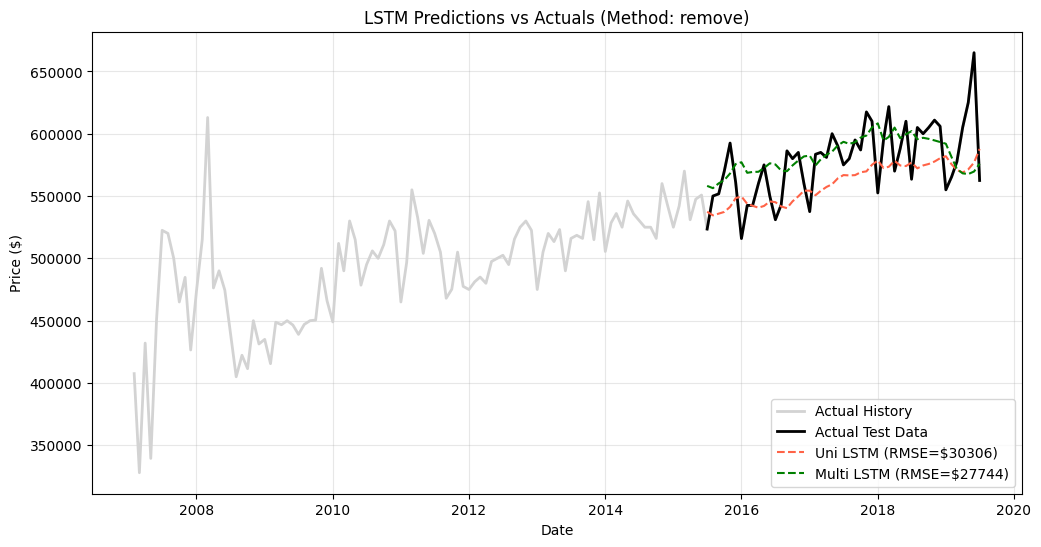


--- Handling outliers with method: log_transform ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Univariate LSTM RMSE:   $32,833.67
Multivariate LSTM RMSE: $36,407.39


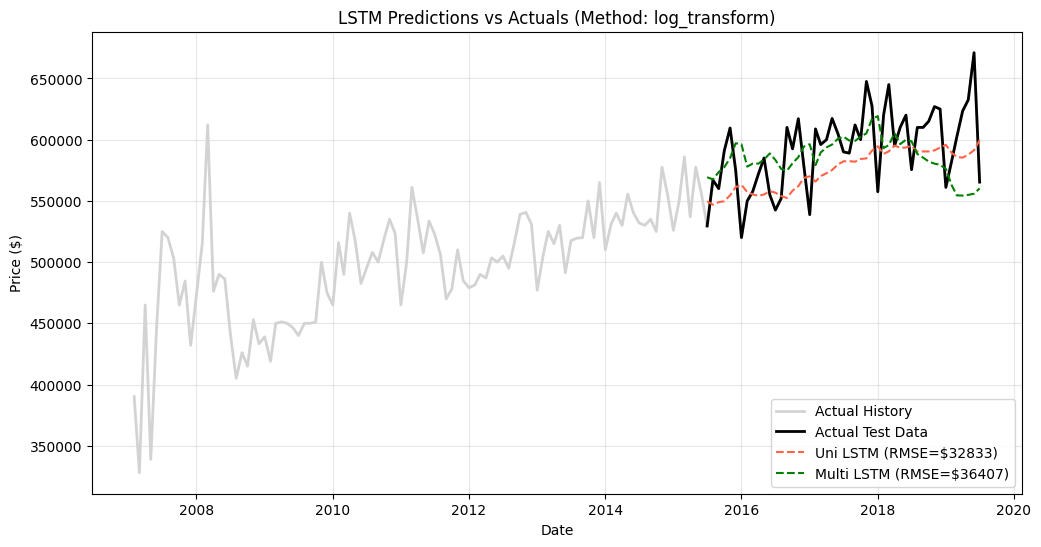

In [123]:
from sklearn.metrics import mean_squared_error
import math

# Function to calculate RMSE in Dollars
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Modified loop to handle inverse transformation and plotting correctly
for type_of_outlier in ['none', 'remove', 'log_transform']: #'power_transform']:
    print(f"\n--- Handling outliers with method: {type_of_outlier} ---")

    # 1. Get Cleaned Data (Note: 'remove' changes the data length and medians!)
    df_cleaned, monthly, monthly_df_cleaned = pipeline(df, type_of_outlier=type_of_outlier, plotting=False)

    # 2. Run Models (These return values in the model's scale: Dollars or Log-Dollars)
    preds_multi, y_multi, _ = run_lstm_multivariate(monthly_df_cleaned, train_size=train_size)
    preds_uni, y_uni, _ = run_lstm_univariate(monthly_df_cleaned, train_size=train_size)

    # 3. Inverse Transform EVERYTHING to Dollars for consistent evaluation
    if type_of_outlier == 'log_transform':
        # Model predicted Log-Price, convert to Price
        actual_dollar = np.exp(y_uni)
        pred_uni_dollar = np.exp(preds_uni)
        pred_multi_dollar = np.exp(preds_multi)
        # Get full history in dollars for context
        history_dollar = np.exp(monthly_df_cleaned['price'].values)
    else:
        # Model predicted Price directly
        actual_dollar = y_uni
        pred_uni_dollar = preds_uni
        pred_multi_dollar = preds_multi
        history_dollar = monthly_df_cleaned['price'].values

    # 4. Calculate RMSE (Interpretable Error in $)
    rmse_uni = calculate_rmse(actual_dollar, pred_uni_dollar)
    rmse_multi = calculate_rmse(actual_dollar, pred_multi_dollar)
    
    print(f"Univariate LSTM RMSE:   ${rmse_uni:,.2f}")
    print(f"Multivariate LSTM RMSE: ${rmse_multi:,.2f}")

    # 5. Plotting (Aligned correctly)
    seq_len = 12
    # The predictions correspond to the END of the dataset (Test set)
    test_start_idx = len(monthly_df_cleaned) - len(actual_dollar)
    
    # Dates for the test set
    test_dates = monthly_df_cleaned.index[test_start_idx:]
    full_dates = monthly_df_cleaned.index

    plt.figure(figsize=(12, 6))
    
    # Plot Full History
    plt.plot(full_dates, history_dollar, label='Actual History', color='lightgray', linewidth=2)
    plt.plot(test_dates, actual_dollar, label='Actual Test Data', color='black', linewidth=2)
    
    # Plot Predictions
    plt.plot(test_dates, pred_uni_dollar, label=f'Uni LSTM (RMSE=${int(rmse_uni)})', color='tomato', linestyle='--')
    plt.plot(test_dates, pred_multi_dollar, label=f'Multi LSTM (RMSE=${int(rmse_multi)})', color='green', linestyle='--')

    plt.title(f'LSTM Predictions vs Actuals (Method: {type_of_outlier})')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# NEXT TOPICS

In [124]:
#TODO: does rmse really mean money?
#TODO: which is the metric that is to be used in this case? rmse, mape, mae, mse?
#TODO: why do 'none' and 'remove' have better rmse than log transform?
#TODO: understand why multivariate works worse than univariate in this case. Why NOT considering the other features (house_ratio, avg_bedrooms, sales_count) leads to better predictions? Is it because of the small dataset size? Or because those features are not actually predictive of price in this dataset?
#TODO: shap explanations for the multivariate LSTM model, to understand how the different features (avg_bedrooms, house_ratio, sales_count) are influencing the predictions of the median price over time.
#TODO: add year/month seasonality to the model, since we know that house prices can be influenced by seasonality (e.g., higher prices in spring/summer). We can add month and year as additional features to the multivariate LSTM model, and then analyze their importance using SHAP values to see how they contribute to the predictions.
#TODO: can we somehow include geographical information into the model? (e.g., using postcode as a feature, or clustering postcodes into regions and using region as a feature)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


100%|██████████| 20/20 [00:03<00:00,  5.36it/s]


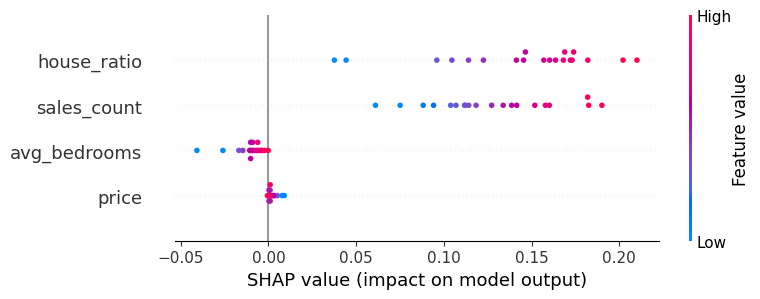

In [125]:
import shap

def run_lstm_multivariate(monthly_df_cleaned, train_size):

    '''
    This function runs a multivariate LSTM model using the 'avg_bedrooms', 'house_ratio', and 'sales_count' features from monthly_df_cleaned to predict the 'price' target.
    It scales the features and target, creates sequences, trains the LSTM, and returns predictions, actual values, and MSE.
    Multivariate means we are using multiple features (avg_bedrooms, house_ratio, sales_count) to predict the price, which allows the model to learn from the relationships between these features and the target variable.
    '''

    features = ['avg_bedrooms', 'house_ratio', 'sales_count', 'price']
    target = 'price'

    # ----- Scale data -----
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_scaled = scaler_X.fit_transform(monthly_df_cleaned[features])
    y_scaled = scaler_y.fit_transform(monthly_df_cleaned[[target]])

    # ----- Create sequences -----
    seq_len = 12
    X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_len)

    split_idx = int(len(X_seq) * train_size)
    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

    # ----- Build model -----
    model = Sequential([
        LSTM(64, return_sequences=False, input_shape=(seq_len, X_train.shape[2])),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=40, batch_size=16, verbose=0)

    # ----- Predict -----
    preds_scaled = model.predict(X_test)
    preds = scaler_y.inverse_transform(preds_scaled)
    y_test_real = scaler_y.inverse_transform(y_test)

    mse = mean_squared_error(y_test_real, preds)

    return model, X_train, X_test, preds, y_test_real, mse

# 1. Define the features we used
features_list = ['price', 'avg_bedrooms', 'house_ratio', 'sales_count']

# 2. Train the model with these features
# Note: We capture the model and data from the updated function return
model_multi, X_train_multi, X_test_multi, _, _, _ = run_lstm_multivariate(monthly_df_cleaned, train_size)

# 3. Use SHAP KernelExplainer (model-agnostic, works well with TF 2.x)
# We summarize the training data (e.g., first 50 samples) as background,
# using only the latest time step in each sequence.
X_train_last = X_train_multi[:50, -1, :]  # (background_samples, features)
X_test_last = X_test_multi[:20, -1, :]    # (samples_to_explain, features)

# Helper prediction function that maps 2D feature input to the LSTM's 3D input
seq_len_local = X_train_multi.shape[1]

def lstm_predict_last(x):
    # x has shape (n_samples, n_features)
    # Repeat the last-timestep features across the full sequence length
    x_seq = np.tile(x[:, np.newaxis, :], (1, seq_len_local, 1))
    # Return 1D array of predictions for KernelExplainer
    return model_multi.predict(x_seq, verbose=0).ravel()

explainer = shap.KernelExplainer(lstm_predict_last, X_train_last)

# 4. Calculate SHAP values for the test set (may take a little time)
shap_values = explainer.shap_values(X_test_last, nsamples=100)

# 5. Visualize feature importance for the latest time step
shap.initjs()  # Required if running in Jupyter
shap.summary_plot(
    shap_values, 
    X_test_last, 
    feature_names=features_list,
    title="Feature Importance at Prediction Time (t)"
)

In [126]:
%pip install statsmodels pmdarima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

Note: you may need to restart the kernel to use updated packages.


In [128]:
df = pd.read_csv('raw_sales.csv')
df = df.rename(columns={'datesold': 'date', 'propertyType': 'type'})
df['date'] = pd.to_datetime(df['date'])
df = imputer_pipeline(df)
df_cleaned, monthly, monthly_df_cleaned = pipeline(df, type_of_outlier='log_transform', plotting=False)

monthly_df = monthly_df_cleaned.asfreq('MS')

train_size = int(len(monthly_df) * train_size)
train = monthly_df.iloc[:train_size]
test = monthly_df.iloc[train_size:]

y_train = train['price']
y_test  = test['price']
X_train = train[['avg_bedrooms', 'house_ratio', 'sales_count']]
X_test  = test[['avg_bedrooms', 'house_ratio', 'sales_count']]

print(f"Train: {len(train)} | Test: {len(test)}")
print("Train range:", train.index.min(), "→", train.index.max())
print("Test range:", test.index.min(), "→", test.index.max())

auto_model = auto_arima(
    y=y_train,
    exogenous=X_train,
    seasonal=True,
    m=12,                       
    trace=True,                  
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    max_p=3, max_q=3, max_P=2, max_Q=2,
    max_order=None,
    information_criterion='aic'  
)


print("Best model order:", auto_model.order)
print("Best seasonal order:", auto_model.seasonal_order)

Train: 97 | Test: 53
Train range: 2007-02-01 00:00:00 → 2015-02-01 00:00:00
Test range: 2015-03-01 00:00:00 → 2019-07-01 00:00:00
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-222.153, Time=1.90 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-195.800, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-218.014, Time=0.26 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-224.396, Time=0.50 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-197.633, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=-222.396, Time=0.10 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=-223.884, Time=1.33 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=-229.169, Time=1.68 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=-229.566, Time=1.75 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : AIC=inf, Time=1.93 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=-223.963, Time=2.65 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=inf, Time=2.58 sec
 ARIMA(1,1,1)(1,0,2)[12] intercep

In [129]:
model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = model.fit(disp=False)
print(sarimax_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                   price   No. Observations:                   97
Model:             SARIMAX(0, 1, 1)x(1, 0, [1, 2], 12)   Log Likelihood               -1129.245
Date:                                 Thu, 19 Feb 2026   AIC                           2274.491
Time:                                         12:47:53   BIC                           2292.479
Sample:                                     02-01-2007   HQIC                          2281.636
                                          - 02-01-2015                                         
Covariance Type:                                   opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
avg_bedrooms     0.3185         -0       -inf      0.000       0.318  

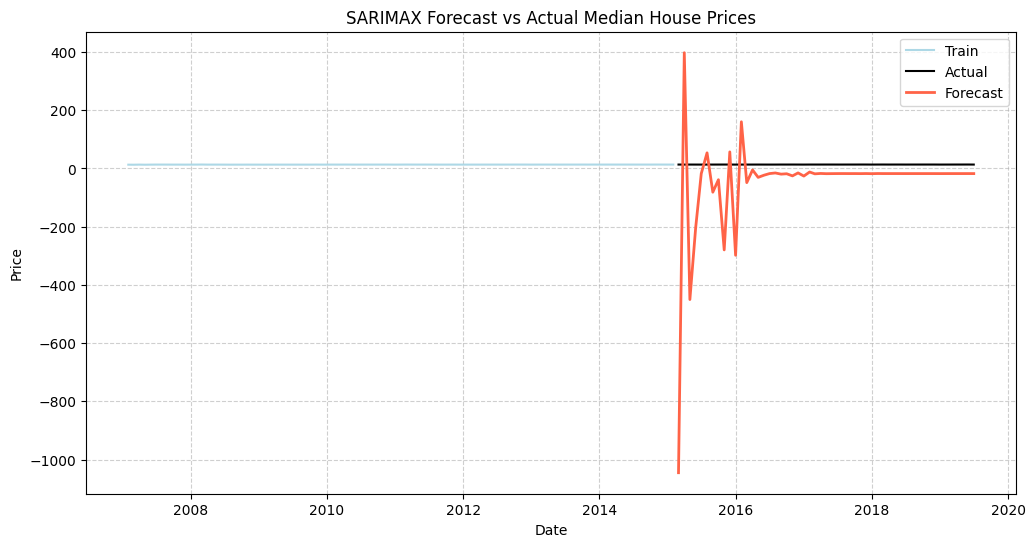

SARIMAX RMSE: $184.01


In [130]:
forecast = sarimax_fit.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test
)

plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Train', color='lightblue')
plt.plot(y_test.index, y_test, label='Actual', color='black')
plt.plot(y_test.index, forecast, label='Forecast', color='tomato', linewidth=2)
plt.title("SARIMAX Forecast vs Actual Median House Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#print RMSE
rmse_sarimax = calculate_rmse(y_test, forecast)
print(f"SARIMAX RMSE: ${rmse_sarimax:,.2f}")